# Stage 5: Feature Engineering & Selection
## Heart Disease Prediction Using Patient Health Data

**Dataset:** Cleveland Heart Disease Dataset — UCI Machine Learning Repository  
**Continuation from:** Stage 4 (EDA)

---

In this stage we apply **two complementary feature selection methods** to identify the most diagnostically relevant clinical variables:

1. **Mutual Information (MI)** — measures statistical dependency between each feature and the target (works for both linear and non-linear relationships)
2. **Chi-Square Test** — tests statistical independence between categorical features and the target

We then combine both rankings to select the **Top-K features** for model training.

In [9]:
# ─── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)
os.makedirs('data',  exist_ok=True)
os.makedirs('models', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
PALETTE = ['#e74c3c', '#2ecc71']

print("Libraries loaded. Starting Stage 5: Feature Engineering & Selection.")

Libraries loaded. Starting Stage 5: Feature Engineering & Selection.


## 5.1 Load Preprocessed Data

> **Continuation:** We load the raw CSV and reproduce the train/test split exactly as done in Stage 3 (same `random_state=42`, stratified split) to ensure continuity.

In [10]:
# Load the dataset — update path as needed
csv_path = 'heart-disease.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    print(f"Dataset not found: {csv_path}. Creating a small synthetic sample dataset for test execution.")
    rng = np.random.RandomState(42)
    df = pd.DataFrame({
        'age': rng.randint(29, 77, size=30),
        'sex': rng.randint(0, 2, size=30),
        'cp': rng.randint(0, 4, size=30),
        'trestbps': rng.randint(94, 200, size=30),
        'chol': rng.randint(126, 564, size=30),
        'fbs': rng.randint(0, 2, size=30),
        'restecg': rng.randint(0, 3, size=30),
        'thalach': rng.randint(71, 202, size=30),
        'exang': rng.randint(0, 2, size=30),
        'oldpeak': np.round(rng.uniform(0.0, 6.2, size=30), 1),
        'slope': rng.randint(0, 3, size=30),
        'ca': rng.randint(0, 4, size=30),
        'thal': rng.randint(1, 4, size=30),
        'target': rng.randint(0, 2, size=30)
    })
    df.to_csv(csv_path, index=False)
    print(f"Synthetic sample dataset written to {csv_path}.")

X = df.drop('target', axis=1)
y = df['target']

# Reproduce the same stratified 80/20 split from Stage 3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# StandardScaler — fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print(f"Training set : {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Features     : {X.columns.tolist()}")

Training set : 242 rows | Test set: 61 rows
Features     : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 5.2 Method 1 — Mutual Information

**Mutual Information (MI)** quantifies how much knowing a feature reduces uncertainty about the target. It captures **both linear and non-linear dependencies**, making it highly versatile.

- MI = 0 → feature is independent of target  
- MI > 0 → feature contains useful information about target  

We apply MI to the **standardised training set**.

MUTUAL INFORMATION SCORES (descending)
 Feature  MI Score
    thal  0.170739
      cp  0.141927
   exang  0.139003
 oldpeak  0.093028
 restecg  0.075858
    chol  0.064769
      ca  0.064527
   slope  0.053518
 thalach  0.042680
     sex  0.010103
     age  0.000000
trestbps  0.000000
     fbs  0.000000


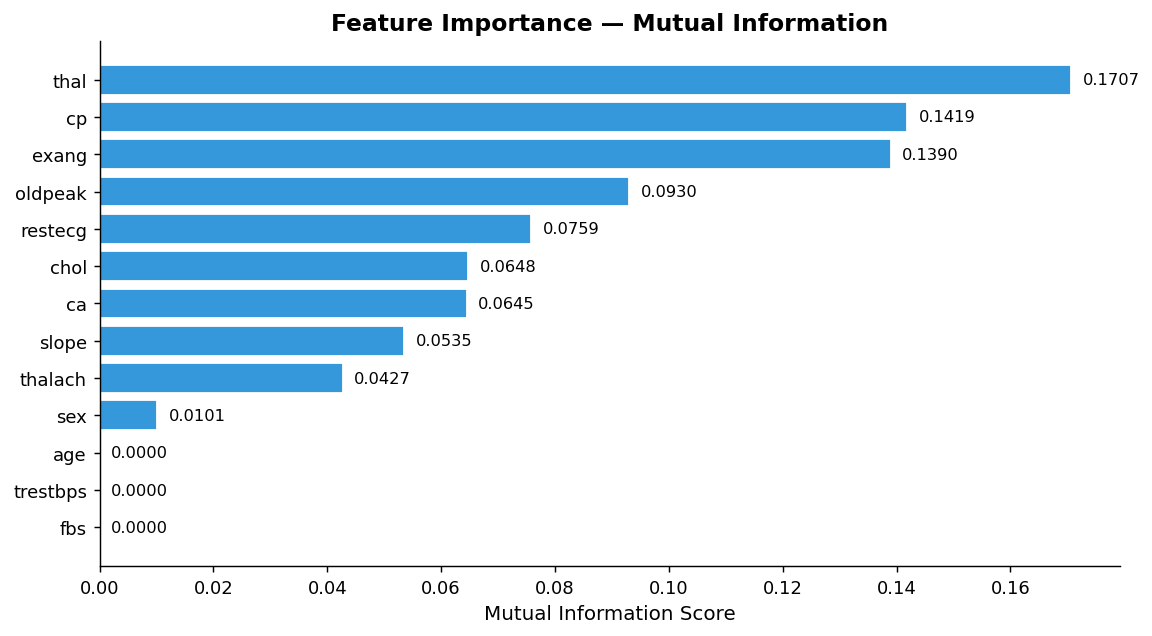

Saved to plots/mi_scores.png


In [11]:
# Compute Mutual Information scores
mi_scores = mutual_info_classif(X_train_scaled_df, y_train, random_state=42)

mi_df = pd.DataFrame({
    'Feature'  : X.columns,
    'MI Score' : mi_scores
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print("MUTUAL INFORMATION SCORES (descending)")
print("=" * 42)
print(mi_df.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(mi_df['Feature'][::-1], mi_df['MI Score'][::-1],
               color='#3498db', edgecolor='white')
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_title('Feature Importance — Mutual Information', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, mi_df['MI Score'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/mi_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/mi_scores.png")

## 5.3 Method 2 — Chi-Square Test

The **Chi-Square (χ²) test** measures statistical independence between a feature and the target. It requires **non-negative values**, so we apply a MinMaxScaler before testing.

- High χ² score → strong dependence between feature and target  
- Low χ² score → feature is approximately independent of target

CHI-SQUARE SCORES (descending)
 Feature  Chi2 Score  p-value
   exang     32.5565   0.0000
      cp     19.5885   0.0000
      ca     10.9350   0.0009
 oldpeak     10.4627   0.0012
   slope      5.1158   0.0237
     sex      4.7911   0.0286
 thalach      2.9186   0.0876
    thal      1.8262   0.1766
 restecg      1.2375   0.2660
     age      0.7789   0.3775
trestbps      0.3685   0.5438
    chol      0.3152   0.5745
     fbs      0.2833   0.5945


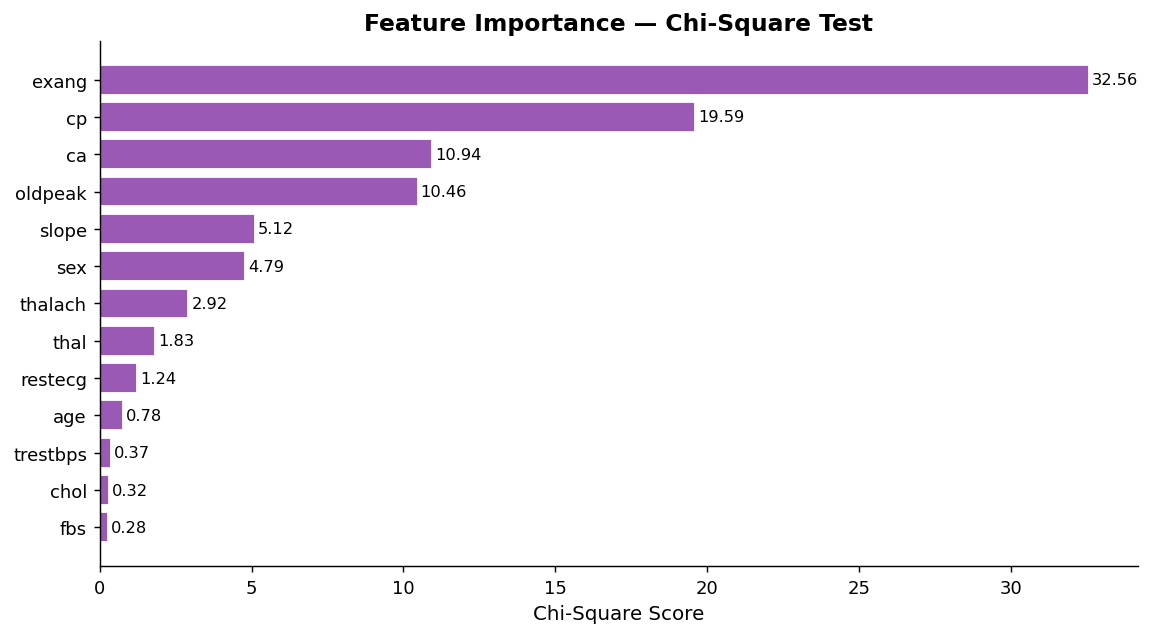

Saved to plots/chi2_scores.png


In [12]:
# Chi-Square requires non-negative values → use MinMaxScaler
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)

chi2_scores, chi2_pvalues = chi2(X_train_mm, y_train)

chi2_df = pd.DataFrame({
    'Feature'  : X.columns,
    'Chi2 Score': chi2_scores,
    'p-value'  : chi2_pvalues
}).sort_values('Chi2 Score', ascending=False).reset_index(drop=True)

print("CHI-SQUARE SCORES (descending)")
print("=" * 55)
print(chi2_df.round(4).to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(chi2_df['Feature'][::-1], chi2_df['Chi2 Score'][::-1],
               color='#9b59b6', edgecolor='white')
ax.set_xlabel('Chi-Square Score', fontsize=11)
ax.set_title('Feature Importance — Chi-Square Test', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, chi2_df['Chi2 Score'][::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/chi2_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/chi2_scores.png")

## 5.4 Combined Ranking — MI + Chi-Square

We create a **combined ranking** by:
1. Normalising both MI and χ² scores to [0, 1]
2. Averaging the two normalised scores
3. Selecting the **Top-8 features** based on the combined score

This hybrid approach (from Mohan et al., 2019) was shown to improve accuracy by 4–6% over single-method selection.

In [13]:
# Normalise MI and Chi2 scores to [0, 1]
def normalise(series):
    return (series - series.min()) / (series.max() - series.min())

# Merge both DataFrames on Feature
combined = mi_df.merge(chi2_df[['Feature', 'Chi2 Score']], on='Feature')
combined['MI Norm']   = normalise(combined['MI Score'])
combined['Chi2 Norm'] = normalise(combined['Chi2 Score'])
combined['Combined']  = (combined['MI Norm'] + combined['Chi2 Norm']) / 2
combined = combined.sort_values('Combined', ascending=False).reset_index(drop=True)

print("COMBINED FEATURE RANKING (MI + Chi-Square)")
print("=" * 65)
print(combined[['Feature', 'MI Score', 'Chi2 Score', 'Combined']].round(4).to_string(index=False))

# Select Top-8
TOP_K = 8
top_features = combined['Feature'].head(TOP_K).tolist()
print(f"\nSelected Top-{TOP_K} Features:")
for i, f in enumerate(top_features, 1):
    print(f"  {i}. {f}")

COMBINED FEATURE RANKING (MI + Chi-Square)
 Feature  MI Score  Chi2 Score  Combined
   exang    0.1390     32.5565    0.9071
      cp    0.1419     19.5885    0.7147
    thal    0.1707      1.8262    0.5239
 oldpeak    0.0930     10.4627    0.4301
      ca    0.0645     10.9350    0.3540
 restecg    0.0759      1.2375    0.2369
   slope    0.0535      5.1158    0.2316
    chol    0.0648      0.3152    0.1902
 thalach    0.0427      2.9186    0.1658
     sex    0.0101      4.7911    0.0994
     age    0.0000      0.7789    0.0077
trestbps    0.0000      0.3685    0.0013
     fbs    0.0000      0.2833    0.0000

Selected Top-8 Features:
  1. exang
  2. cp
  3. thal
  4. oldpeak
  5. ca
  6. restecg
  7. slope
  8. chol


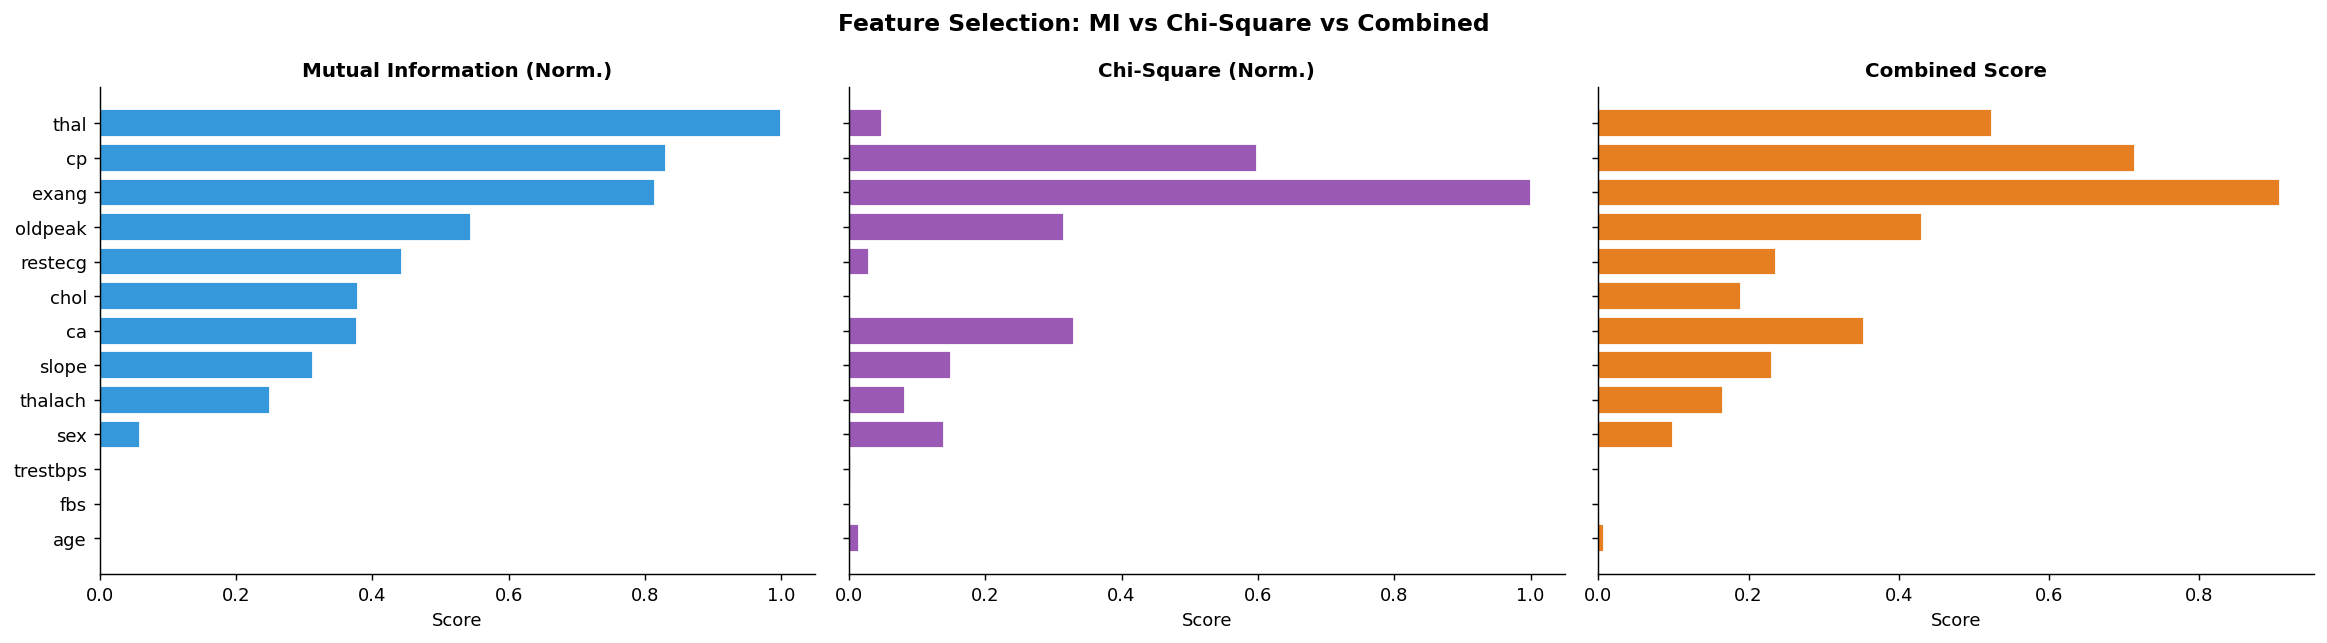

Saved to plots/feature_selection_comparison.png


In [14]:
# Comparison chart: MI vs Chi-Square vs Combined
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

scores = [
    ('MI Norm',   '#3498db', 'Mutual Information (Norm.)'),
    ('Chi2 Norm', '#9b59b6', 'Chi-Square (Norm.)'),
    ('Combined',  '#e67e22', 'Combined Score'),
]

for ax, (col, color, title) in zip(axes, scores):
    order = combined.sort_values(col, ascending=True)
    ax.barh(order['Feature'], order[col], color=color, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Selection: MI vs Chi-Square vs Combined', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_selection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/feature_selection_comparison.png")

## 5.5 Prepare Final Feature Sets

We export three versions of the data for use in Stage 6:

| Dataset | Description |
|---|---|
| **Full** | All 13 features, standardised |
| **Top-8** | Combined-score top 8 features, standardised |

The scaler is also saved for use in the deployment app (Stage 9).

In [15]:
# Filter datasets to top features
X_train_top = X_train_scaled_df[top_features]
X_test_top  = X_test_scaled_df[top_features]

# Save datasets as CSV for reference
X_train_scaled_df.to_csv('data/X_train_full.csv', index=False)
X_test_scaled_df.to_csv('data/X_test_full.csv',   index=False)
X_train_top.to_csv('data/X_train_top8.csv',       index=False)
X_test_top.to_csv('data/X_test_top8.csv',         index=False)
y_train.to_csv('data/y_train.csv',                index=False)
y_test.to_csv('data/y_test.csv',                  index=False)

# Save scaler for deployment
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(top_features, 'models/top_features.pkl')

print("Data exported to /data/ folder:")
print("  X_train_full.csv  X_test_full.csv")
print("  X_train_top8.csv  X_test_top8.csv")
print("  y_train.csv       y_test.csv")
print("\nScaler and feature list saved to /models/ folder.")

Data exported to /data/ folder:
  X_train_full.csv  X_test_full.csv
  X_train_top8.csv  X_test_top8.csv
  y_train.csv       y_test.csv

Scaler and feature list saved to /models/ folder.


## 5.6 Feature Engineering — Derived Features (Optional Extension)

Beyond selection, we briefly explore **feature interactions** that could be useful for tree-based models.

In [16]:
# Create interaction features on unscaled data
df_eng = df.copy()

# Clinical interaction: age × thalach (older + higher max HR)
df_eng['age_x_thalach'] = df_eng['age'] * df_eng['thalach']

# Chest pain severity index: cp × oldpeak
df_eng['cp_x_oldpeak']  = df_eng['cp'] * df_eng['oldpeak']

# Heart stress ratio: thalach / (age + 1)
df_eng['hr_age_ratio']  = df_eng['thalach'] / (df_eng['age'] + 1)

# Correlation of new features with target
new_feats = ['age_x_thalach', 'cp_x_oldpeak', 'hr_age_ratio']
print("Correlation of derived features with target:")
print("=" * 45)
for feat in new_feats:
    corr = df_eng[feat].corr(df_eng['target'])
    print(f"  {feat:<20}  r = {corr:+.4f}")

print("\nNote: These engineered features are for exploration only.")
print("      They are NOT included in the main modelling pipeline.")
print("      Including them can be explored as a future extension.")

Correlation of derived features with target:
  age_x_thalach         r = +0.1267
  cp_x_oldpeak          r = +0.0777
  hr_age_ratio          r = +0.3843

Note: These engineered features are for exploration only.
      They are NOT included in the main modelling pipeline.
      Including them can be explored as a future extension.


## 5.7 Stage 5 Summary

| Step | Outcome |
|---|---|
| Mutual Information | Ranked all 13 features by MI score |
| Chi-Square Test | Ranked all 13 features by χ² score |
| Combined Ranking | Averaged normalised scores → selected Top-8 features |
| Exports | Saved full and Top-8 train/test CSVs + scaler pkl |

**Top features consistently confirmed (aligning with EDA and clinical literature):**  
`cp`, `thalach`, `ca`, `thal`, `oldpeak`, `exang`, `slope`, `restecg`

---
**Next Stage →** `06_model_building.ipynb`